# Friction Modeling



## Setup from Physically Feasible Dynamic Parameter Identification of the WAM Robot 7-DOF

### to run after setting up Amir's conda env 'id':
- python3 -m pip install sympy==0.7.5
- conda install matplotlib
- conda install scikit-learn

In [230]:
datafolder = 'data/'
tmpfolder = 'tmp/'
from sympy import init_printing
init_printing()

%matplotlib inline
import sympybotics

In [231]:
# rbtdef = sympybotics.RobotDef("WAM Arm 7 DOF",
#             [("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q"),
#              ("pi/2", -0.045, 0, "q"),
#              ("-pi/2", 0, 0.3, "q"),
#              ("pi/2", 0, 0, "q"),
#              (0, 0, 0.06, "q")],
#             dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM 2-DOF",
#     [("-pi/2", 0, 0, "q"),
#      (0, 0.045, 0.55, "q")],
#     dh_convention="standard"
# )

rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
            [("-pi/2", 0, 0, "q"),
             ("pi/2", 0, 0, "q"),
             ("-pi/2", 0.045, 0.55, "q"),
             ("pi/2", -0.045, 0, "q")],
            dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
#             [(0, 0, 0, "q"),|
#              ("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q")],
#             dh_convention="standard")
rbtdef.frictionmodel = {'Coulomb', 'viscous'}

In [232]:
import math
import numpy
from math import pi

# Register them in global scope for exec() to see
import builtins
builtins.math = math
builtins.numpy = numpy
builtins.pi = pi

from sympy import iterables


In [233]:
%time rbt = sympybotics.RobotDynCode(rbtdef)
%time rbt.calc_base_parms()

CPU times: user 1.41 s, sys: 1.56 ms, total: 1.41 s
Wall time: 1.41 s
CPU times: user 1.37 s, sys: 11.7 ms, total: 1.38 s
Wall time: 1.14 s


In [234]:
import pickle
with open(tmpfolder + 'robotmodels/wam4_model.pkl', 'wb') as file:
    pickle.dump( rbt, file )

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

rbt.dyn.n_dynparms, rbt.dyn.n_base

rbt.dyn.dynparms.n()
rbt.dyn.baseparms.n()

Matrix([
[                                                 L_1yy + L_2zz],
[                                                          fv_1],
[                                                          fc_1],
[L_2xx - L_2zz + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2xy],
[                                                         L_2xz],
[        L_2yy + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2yz],
[                                                          l_2x],
[                             l_2z - l_3y + 0.55*m_3 + 0.55*m_4],
[                                                          fv_2],
[                                                          fc_2],
[                          L_3xx - L_3zz + L_4zz + 0.002025*m_3],
[                                            L_3xy - 0.045*l_3y],
[                                                         L_3xz],
[

In [235]:
import numpy as np

# Step 1: Convert symbolic matrix to NumPy array
Pb_matrix = np.array(rbt.dyn.Pb.tolist(), dtype=np.float64)  # already 0/1
Pb_flat = Pb_matrix.flatten()

# Step 2: Generate C++ code
cpp_array_str = 'double Pb[1440] = {\n'
for i, val in enumerate(Pb_flat):
    cpp_array_str += f'{int(val)}, '  # write as integer 0 or 1
    if (i + 1) % 12 == 0:  # break line every 12 entries
        cpp_array_str += '\n'
cpp_array_str += '};'

with open('Pb_array.cpp', 'w') as f:
    f.write(cpp_array_str)

## Load Data

(15000, 4)
(15001, 9)
(15000, 4)


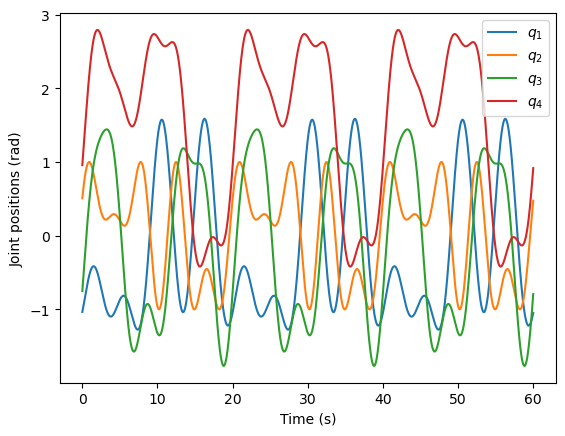

In [236]:
import pickle
import sympybotics
import numpy

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

h = 0.004
decimate = 1
h_plot = h*decimate # downsample it so that it has the frequency of 500 (originally it has been 1000)

with open(datafolder +  'trajectories/traj_4.dat', 'r' ) as file:
          q_ref_orig = numpy.loadtxt(file)
print(q_ref_orig.shape)
q_ref = q_ref_orig
with open(datafolder +  'recdata/rbtlog_4_dof.dat', 'r' ) as file:
          q_raw_orig = numpy.loadtxt(file)
print(q_raw_orig.shape)
s = q_ref_orig.shape[0] // decimate

q_ref = numpy.zeros((s, rbt.dof))
for i in range(s):
    q_ref[i, :] = q_ref_orig[i*decimate, :]
print(q_ref.shape)

si = 0
sf = si + 60/h_plot
t = numpy.arange(sf-si) * h_plot

from matplotlib import pyplot as plt
plt.close()

si = int(si)
sf = int(sf)

for i in range(rbt.dof):
    plt.plot(t,q_ref[si:sf,i], label="$q_%d$"%(i+1))
plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Joint positions (rad)")

plt.show()

## Regression Setup



In [237]:
import os
import pickle
import math
import sympy
import numpy
import sympybotics

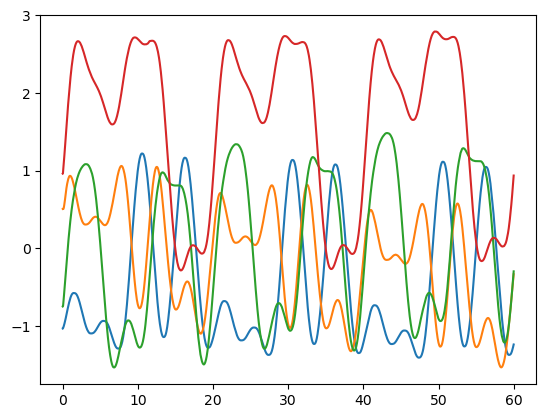

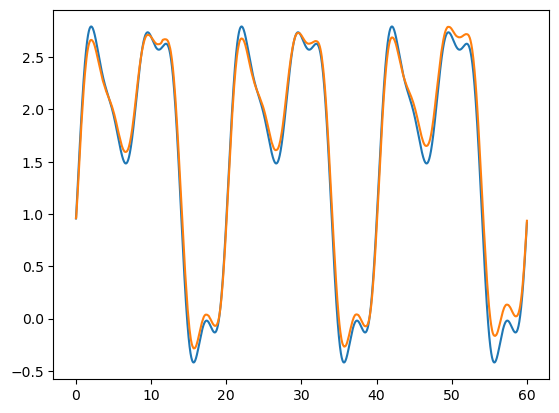

In [238]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

from support_funcs.regr_data_proc import read_data
t_raw, q_raw, tau_raw, t_ref, q_ref = read_data( rbt.dof, 0.004,
                                                datafolder + 'recdata/rbtlog_4_dof.dat',
                                                datafolder + 'trajectories/traj_4.dat')
t_raw = t_raw - t_raw[0]

from matplotlib import pyplot as plt
plt.close()

for i in range(q_raw.shape[1]):
    plt.plot(t_raw,q_raw[:,i])

plt.show()

from matplotlib import pyplot as plt
plt.close()

joint = 4
plt.plot(t_ref,q_ref[:,joint-1])
plt.plot(t_raw,q_raw[:,joint-1])

plt.show()

del t_raw, q_raw, tau_raw, t_ref, q_ref

In [239]:
# with open(datafolder +  'trajectories/traj_shwfl_abq0.pkl', 'rb' ) as file:
#           s_h_wf_l, a_b_q0 = pickle.load(file)
with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

print(dict(zip(('S', 'h', 'wf', 'L'), s_h_wf_l)))
print('\n')

fc_mult = 10

wf = float(s_h_wf_l[2])
L = float(s_h_wf_l[3])
fc = fc_mult * ( wf / (2*math.pi) * L )
fc

fc_q = fc
fc_dq = fc
fc_ddq = fc

fc_tau = fc

si = int(3/0.001)
sf = -int(1/0.001)-172

{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}




In [240]:
rec_h = 0.004 # sampling time
from support_funcs.regr_data_proc import read_data, diff_and_filt_data, gen_regr_matrices
from support_funcs.utils import _fprint

t_raw, q_raw, tau_raw, t_ref, q_ref = read_data(dof=rbt.dof, h=rec_h,
                                                rbtlogfile=datafolder + 'recdata/rbtlog_4_dof.dat',
                                                trajreffile=datafolder + 'trajectories/traj_4.dat')

q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

t_raw = t_raw[si:sf]; q_raw = q_raw[si:sf]; tau_raw = tau_raw[si:sf]
q = q[si:sf]; dq = dq[si:sf]; ddq = ddq[si:sf]; tau = tau[si:sf]

t_raw = t_raw - t_raw[0]

t = numpy.array(range(q.shape[0])) * rec_h
print(np.shape(q))
H_S, W, omega, Q1, R1, rho1 = gen_regr_matrices(rbt, q, dq, ddq, tau)

# W is the regression matrix to appropriately find tau_rbd


_fprint(' (cond=%f)'%numpy.linalg.cond(W))

_fprint('save')

%time \
numpy.savez_compressed(tmpfolder + 'procdata/raw', t=t_raw, q=q_raw, tau=tau_raw);\
numpy.savez_compressed(tmpfolder + 'procdata/proc', t=t, q=q, dq=dq, ddq=ddq, tau=tau); \
numpy.savez_compressed(tmpfolder + 'procdata/regr', W=W, omega=omega, Q1=Q1, R1=R1, rho1=rho1)

# del t_raw, q_raw, tau_raw, t, q, dq, ddq, tau, W, omega, Q1, R1, rho1


(10829, 4)
 (cond=37.423781)
save
CPU times: user 537 ms, sys: 9.77 ms, total: 546 ms
Wall time: 546 ms


In [241]:
print("W.shape",W.shape)
print("tau.shape:",tau.shape)
tau_vec = tau.reshape(-1)
print(tau_vec.shape)   # (43316,)

W.shape (43316, 30)
tau.shape: (10829, 4)
(43316,)


In [242]:
# rbt.dyn.baseparms
W.size
tau.size

beta, *_ = np.linalg.lstsq(W, tau_vec, rcond=None)
tau_rbd = W @ beta #friction from the reduced H_S == W regressor model

In [243]:
print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_rbd = tau_rbd.reshape(-1,1)
tau_vec= tau_vec.reshape(-1,1)

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_residual = tau_vec - tau_rbd

rmse = np.sqrt(np.mean(np.square((tau_residual))))

rmse 
# rbd model:
    #include only viscous ==> rmse = 1.16
    #include both colomnb and viscous ==> rmse = 0.814

tau_rbd.shape (1, 43316)
tau_vec.shape (43316,)
tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)


0.814101787022232

tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)


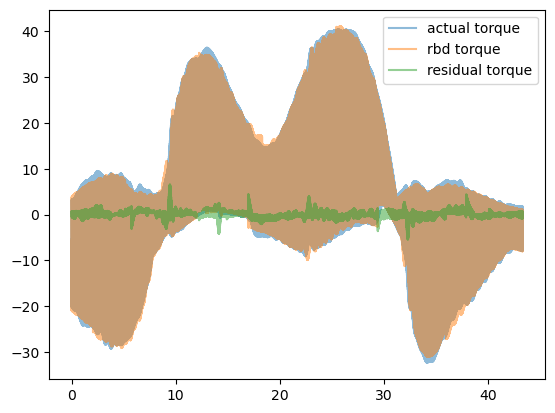

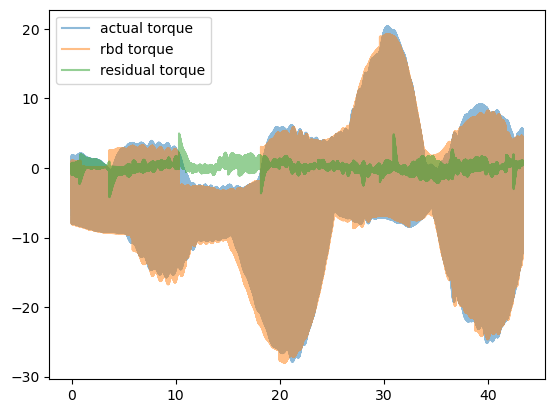

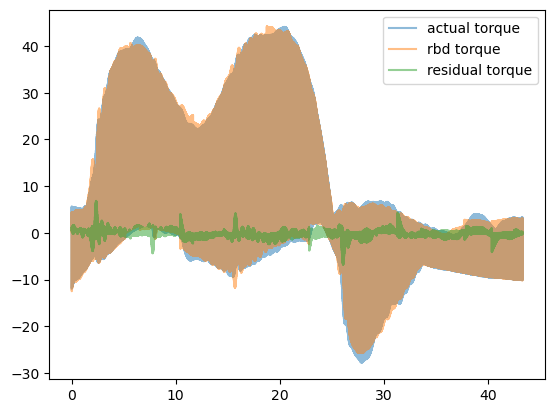

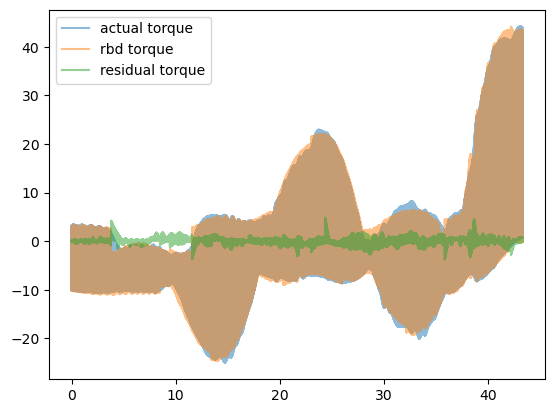

In [244]:
######################################
# Visualize the torques in each joint #
######################################

from matplotlib import pyplot as plt
plt.close()

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    steps = tau_vec.shape[0]
    j = steps//rbt.dof

    plt.plot(t, tau_vec[j*i:j*(i+1)], alpha = 0.5, label='actual torque') # actual torque
    plt.plot(t, tau_rbd[j*i:j*(i+1)],  alpha = 0.5,  label='rbd torque') # modeled by rbd
    plt.plot(t, tau_residual[j*i:j*(i+1)],  alpha = 0.5,  label='residual torque') # actual torque
    plt.legend()
    plt.show()


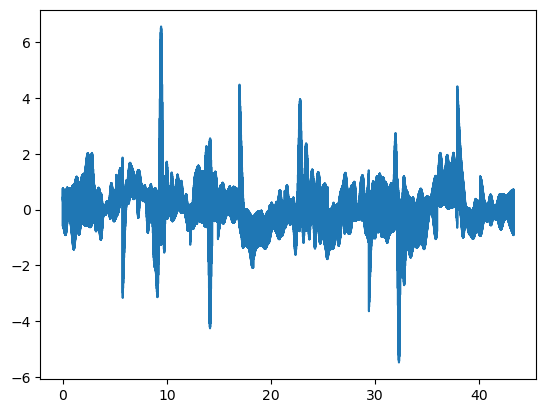

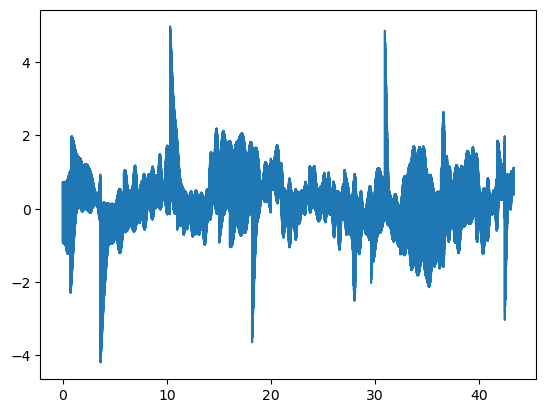

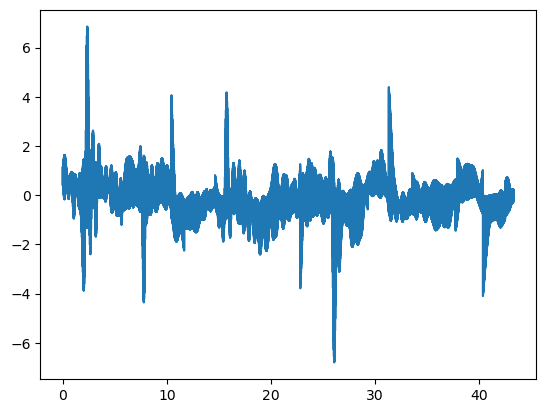

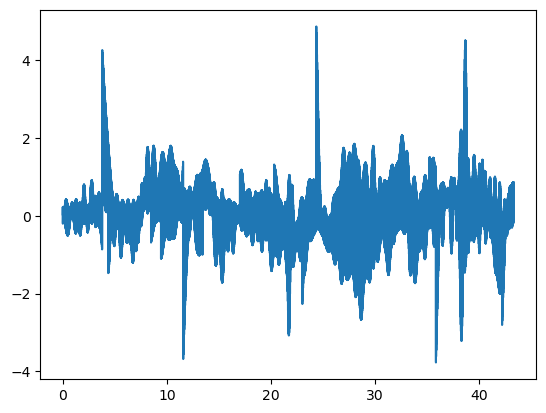

In [245]:
# Visualize only the residual in each joint

# TODO: Do i need to normalize this error when I visualize it?

for i in range(rbt.dof):
    steps = tau_vec.shape[0]
    j = steps//rbt.dof

    plt.plot(t, tau_residual[j*i:j*(i+1)]) # actual torque

    plt.show()

In [246]:
# how good is the tau_vec (TRUE) vs tau_pred (the modeled torques!)

## Friction Modeling

torque_motor = torque_rbd + torque_residual,
(which in the notation used here, torque is represented by tau)
where torque_residual = friction terms (coriolis, stiction, other friction terms that have not been included in the rbd) + other residual terms (noise, unknown)




In [359]:
#get the velocities and accelerations
# q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
#                                fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error

print(q.shape)
print(dq.shape)
print(ddq.shape)

trials_rmse = [] #the error between tau_residual and tau_residual_pred (float)
trials_beta = [] #the regressor vector used (each trial may have a different size of regressor vector)
trials_basis_type = []
trials_tau_residual_hat = []
#after we have all trials we can also get the number of weights used to see the complexity of the model : - )

#just gonna hard code some reusable terms for my convenience here. add experimental things in 'custom'

# poly_deg = 2

# poly = PolynomialFeatures(degree=deg, include_bias=True)

# trig = 

# # add any trial type to test to append those terms to the regression basis.
# # this is kind of a manual process so just double check the degree for poly/trig/custom etc.
# basis_types = {'Coulomb':f_c_vec, 'viscous':f_v_vec, 'poly':poly, 'trig':trig, 'custom':custom}

# regressor_vec = np.array([

(10829, 4)
(10829, 4)
(10829, 4)


In [360]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

def generate_regressor(
    q,
    dq,
    ddq,
    basis_type,
    poly_deg=2,
    poly_in=None,
    trig_in=None,
    include_bias=True,
):
    """
    Build a regression matrix Phi with rows = samples and columns = basis terms.

    q, dq, ddq: arrays of shape (N, n_dof) or (N,)
    basis_type: iterable like ['Coulomb', 'viscous', 'poly', 'trig']
    """

        # just double check that joint and vel and accel are numpy arr
    q = np.asarray(q)
    dq = np.asarray(dq)
    ddq = np.asarray(ddq)

        # reshaping stuff
    if q.ndim == 1:
        q = q[:, None]
    if dq.ndim == 1:
        dq = dq[:, None]
    if ddq.ndim == 1:
        ddq = ddq[:, None]

        #N is number of 
    N = q.shape[0]
    print("N:", N)

    if poly_in is None:
        poly_in = (q, dq, ddq)
    if trig_in is None:
        trig_in = (q, dq, ddq)

    basis_populated = []

    for b in basis_type:
        if b == 'Coulomb':
            # Coulomb friction basis
            basis_populated.append(np.sign(dq))

        elif b == 'viscous':
            # Viscous friction basis
            basis_populated.append(dq)

        elif b == 'poly':
            X_poly = np.concatenate(poly_in, axis=1)
            poly = PolynomialFeatures(degree=poly_deg, include_bias=False)
            basis_populated.append(poly.fit_transform(X_poly))

        elif b == 'trig':
            X_trig = np.concatenate(trig_in, axis=1)
            sin_terms = np.sin(X_trig)
            cos_terms = np.cos(X_trig)
            basis_populated.append(np.concatenate([sin_terms, cos_terms], axis=1))
        elif b == 'trig_poly': #right now this is broken dont use it
            X_trig = np.concatenate(trig_in, axis=1)
            sin_terms = np.sin(X_trig)
            cos_terms = np.cos(X_trig)
            trig_terms = np.concatenate([sin_terms, cos_terms])
   
            X_poly = np.concatenate(poly_in, axis=1)
            poly = PolynomialFeatures(degree=poly_deg, include_bias=False)
            basis_populated.append(poly.fit_transform(trig_terms))

        else:
            raise ValueError(f"Unknown basis type: {b}")

        print(f"basis type added: {b}. basis: {basis_populated}")

    if include_bias:
        basis_populated.append(np.ones((N, 1)))

    print("FINISHED BASIS:", basis_populated)

    Phi = np.concatenate(basis_populated, axis=1)
    print("Phi shape:", Phi.shape)
    print("Phi:", Phi)
    return Phi

In [361]:
def trial(basis_type):
        # get the regressor matrix 
    Phi = generate_regressor(q,dq,ddq, basis_type)
    
    print("Phi.shape", Phi.shape)
    print("tau.shape", tau.shape)
    print("tau_residual.shape", tau_residual.shape)
    tau_residual.reshape(-1,rbt.dof)
    
    
    beta_hat, *_ = np.linalg.lstsq(Phi, tau_residual, rcond=None)
    
    tau_residual_hat = Phi @ beta_hat
    
    print("tau_residual_hat", tau_residual_hat)
    print("beta_hat", beta_hat)


    
    residual_hat = tau_residual - tau_residual_hat
    
    rmse_hat = np.sqrt(np.mean(np.square((residual_hat))))
    print("rmse_hat", rmse_hat)
    
    trials_beta.append(beta_hat)
    trials_rmse.append(rmse_hat)
    trials_basis_type.append(basis_type)
    trials_tau_residual_hat.append(tau_residual_hat)
    return rmse_hat
    

In [362]:
# Trial
fp="poly"
fC="Coulomb"
ft="trig"
fv="viscous"
ftp = 'trig_poly'

# basis_types = [[fp],[fC],[ft],[fp,fC],[fp,ft],[fC,ft],[fp,fC,ft]]
basis_types = [[ft],[fC, ft, fp], [fC],[fp],[ft]]
# Phi beta = torque_residual

tau_residual= tau_residual.reshape(-1,rbt.dof)

for b in basis_types:
    trial(b)

N: 10829
basis type added: trig. basis: [array([[ 0.05065522,  0.7338186 ,  0.19218683, ...,  0.20400523,
         0.9987419 ,  0.9170236 ],
       [ 0.04537108,  0.73605342,  0.19686597, ...,  0.21278771,
         0.99838567,  0.90894721],
       [ 0.04008431,  0.7382656 ,  0.20154151, ...,  0.21664346,
         0.99903269,  0.90275026],
       ...,
       [ 0.38237544, -0.94893603,  0.90066925, ...,  0.69744998,
         0.99999999,  0.63239219],
       [ 0.3868237 , -0.94870525,  0.90066245, ...,  0.70400524,
         0.99971183,  0.5930202 ],
       [ 0.39125109, -0.94846996,  0.90065549, ...,  0.71135725,
         0.99889956,  0.54606554]])]
FINISHED BASIS: [array([[ 0.05065522,  0.7338186 ,  0.19218683, ...,  0.20400523,
         0.9987419 ,  0.9170236 ],
       [ 0.04537108,  0.73605342,  0.19686597, ...,  0.21278771,
         0.99838567,  0.90894721],
       [ 0.04008431,  0.7382656 ,  0.20154151, ...,  0.21664346,
         0.99903269,  0.90275026],
       ...,
       [ 0.38237

In [363]:
trials_rmse

[0.634261441487305,
 0.3154862357722761,
 0.7806054964493399,
 0.43269841977207,
 0.634261441487305]

In [364]:
trials_basis_type

[['trig'], ['Coulomb', 'trig', 'poly'], ['Coulomb'], ['poly'], ['trig']]

In [365]:
trials_beta

[matrix([[ 6.27053221e-01,  2.42807081e-01, -1.25299365e-01,
          -1.73539903e-01],
         [ 1.55032712e-01,  2.63328365e-01,  9.67381202e-01,
          -8.54183820e-02],
         [-7.53887600e-02, -6.97531226e-01,  2.57432780e-01,
          -2.46590850e-01],
         [ 1.00930635e+00,  9.83754085e-01, -9.02933488e-01,
          -2.07464926e-02],
         [ 1.36190738e-01,  1.17672458e+00, -2.69804299e-02,
           3.17402916e-01],
         [-9.89313152e-02, -2.22686535e-02, -4.08793944e-01,
          -8.49595572e-03],
         [ 6.83917389e-01,  1.07337551e+00, -4.23008724e-01,
           6.23602038e-02],
         [-5.81631799e-01, -1.64153215e+00,  2.84463684e-01,
          -3.08148021e-01],
         [ 4.48532250e-01,  2.36424144e-01,  8.75945311e-02,
           1.91529276e-02],
         [ 6.78883791e-02, -9.15123723e-01,  3.99057187e-01,
          -2.81304227e-01],
         [ 4.48294872e-02,  5.02512094e-01,  2.61688437e-01,
           2.42461543e-02],
         [ 2.10877748

In [366]:
trials_tau_residual_hat

[matrix([[ 0.92158228,  0.28856899, -0.19863741, -0.07382135],
         [ 0.92085164,  0.30266346, -0.18242081, -0.07585449],
         [ 0.91981199,  0.30361747, -0.17301165, -0.07817907],
         ...,
         [-0.10184429,  0.82007347, -0.54345048, -0.16264141],
         [-0.079191  ,  0.77376271, -0.53060843, -0.16987781],
         [-0.05091394,  0.72638388, -0.5142419 , -0.17837071]]),
 matrix([[-0.33783661,  0.39168119, -0.4867913 ,  0.39336462],
         [-0.3450331 ,  0.4387429 , -0.48829329,  0.39213672],
         [-0.35238599,  0.48137217, -0.49345966,  0.3923119 ],
         ...,
         [-0.90349162, -0.08786731,  0.61797657, -0.30187932],
         [-0.8226274 , -0.09564725,  0.63691618, -0.31340866],
         [-0.73745632, -0.09785046,  0.65696251, -0.32216378]]),
 matrix([[ 0.3829978 , -0.12569937, -0.19200475, -0.09207043],
         [ 0.3829978 , -0.12569937, -0.19200475, -0.09207043],
         [ 0.3829978 , -0.12569937, -0.19200475, -0.09207043],
         ...,
         

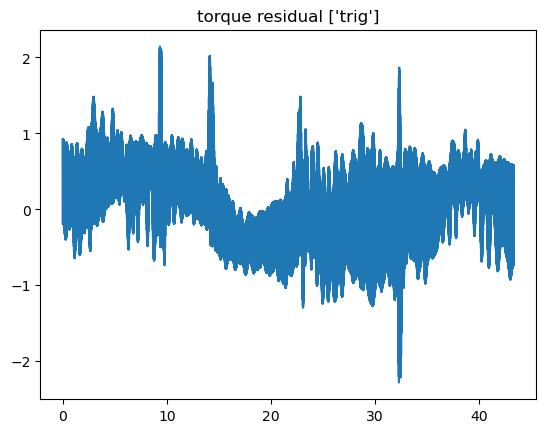

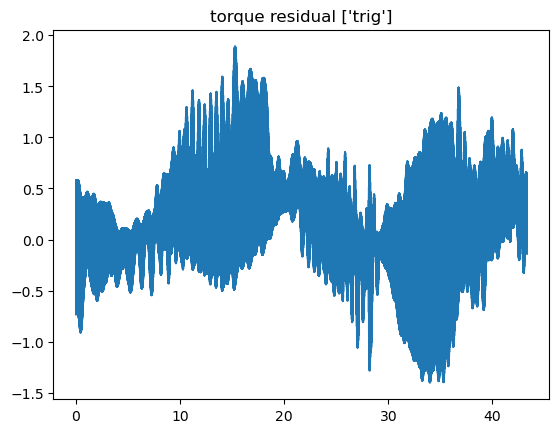

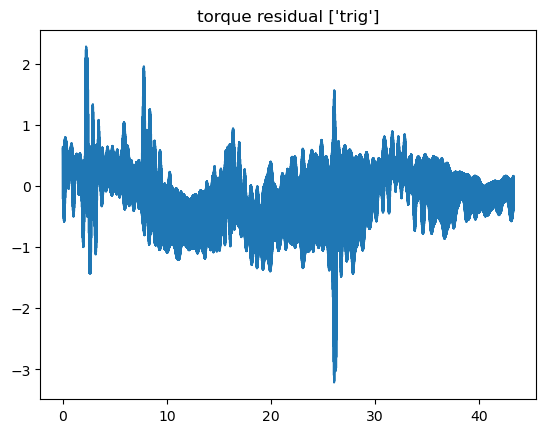

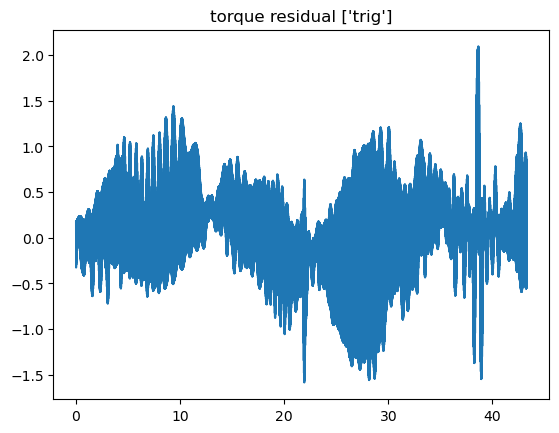

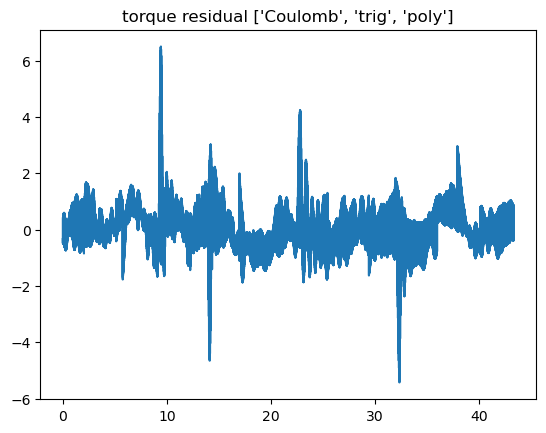

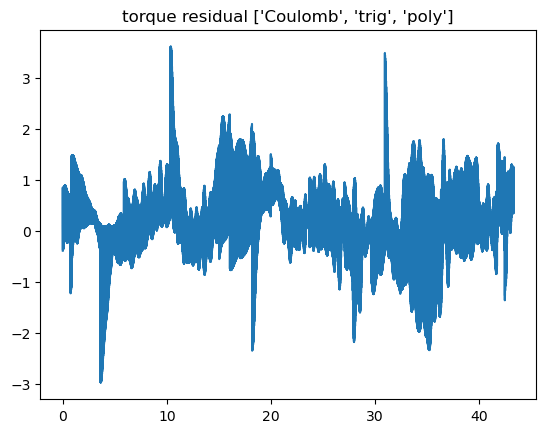

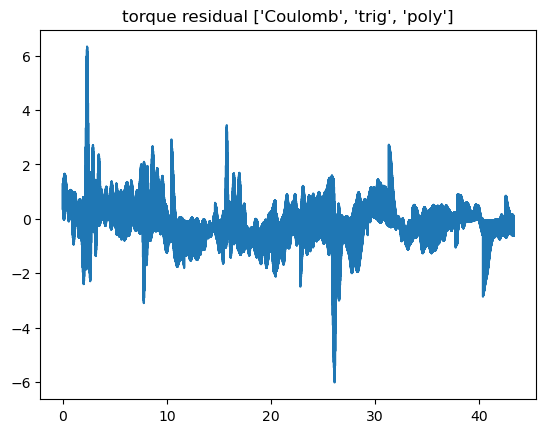

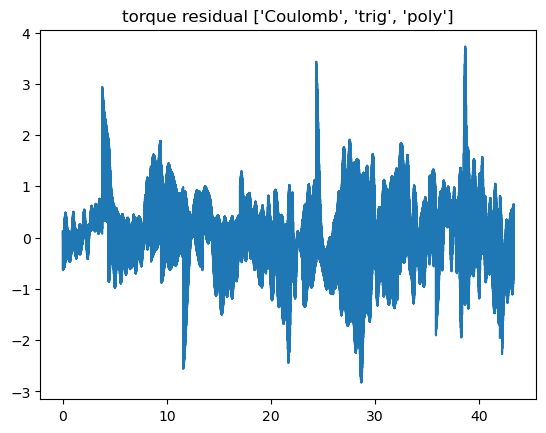

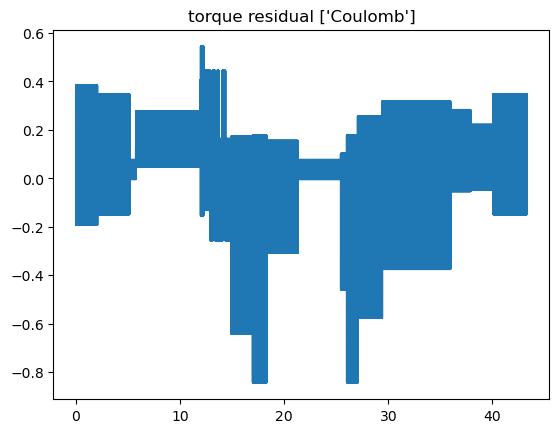

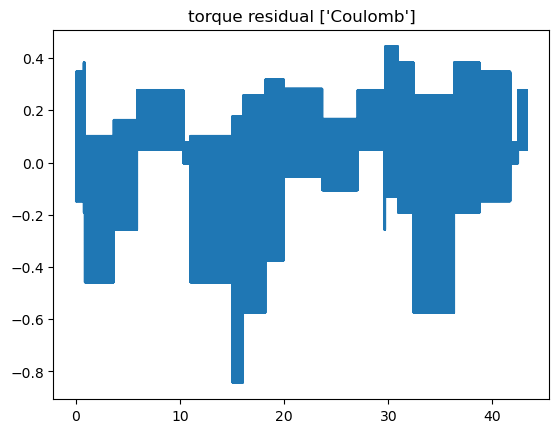

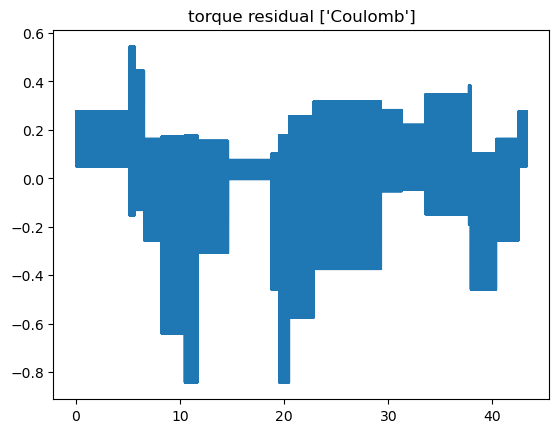

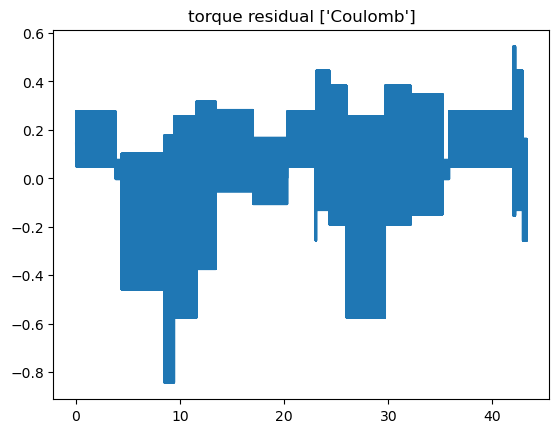

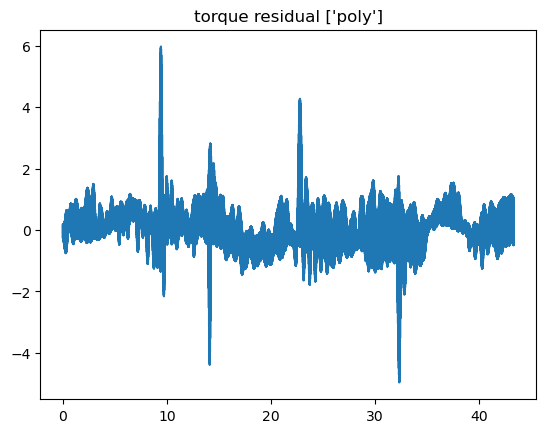

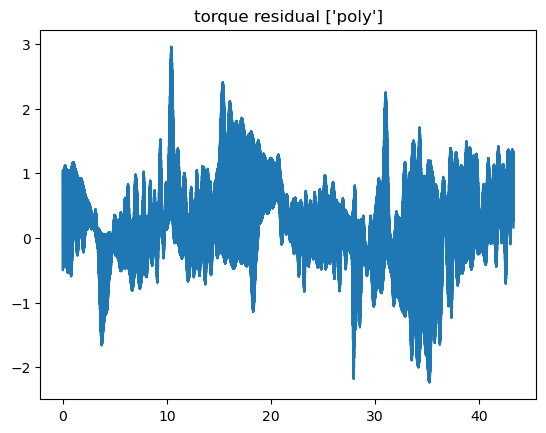

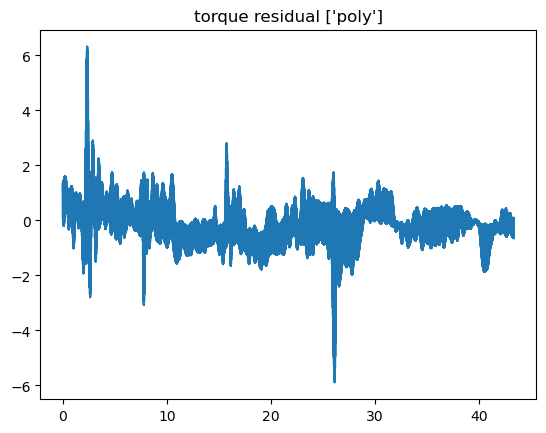

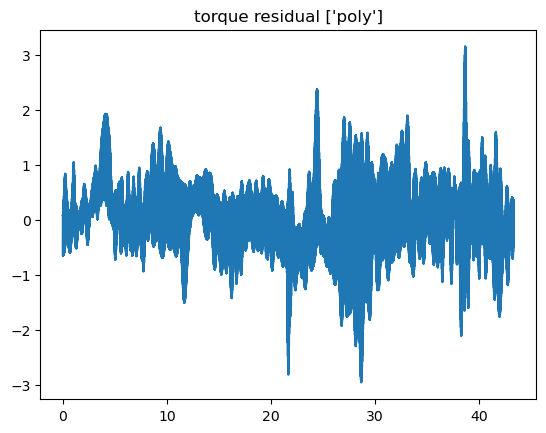

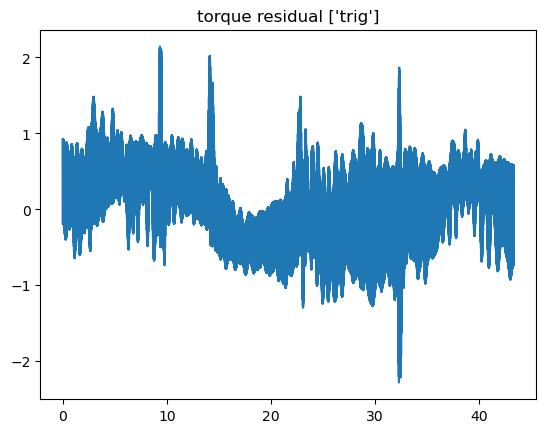

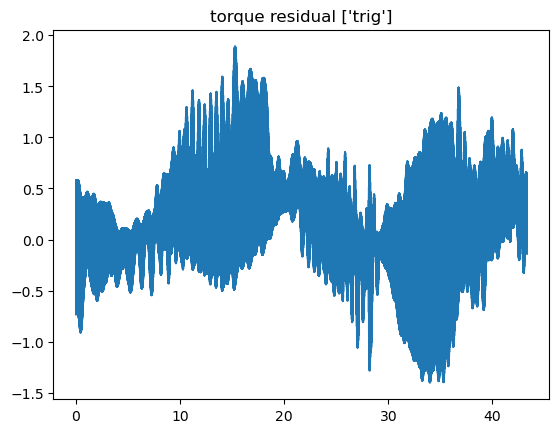

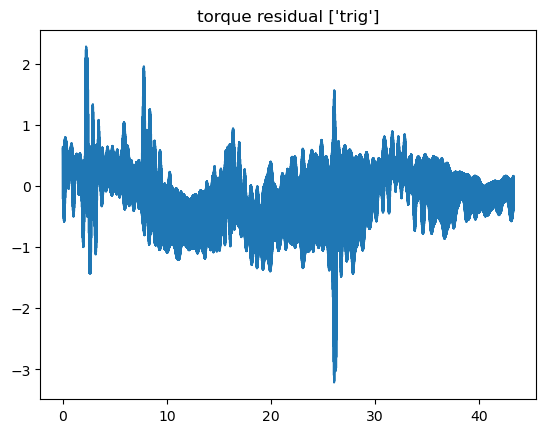

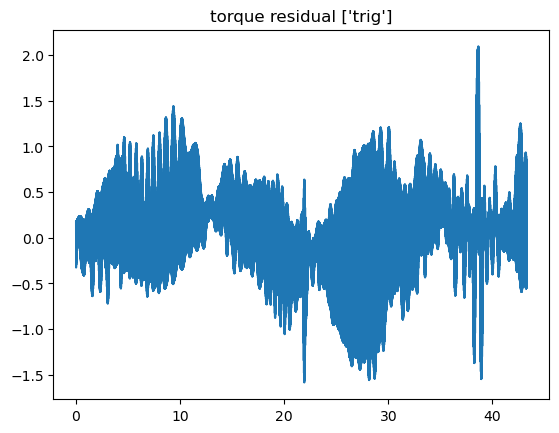

In [367]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################

for _i in range(len(trials_tau_residual_hat)):
    trial = trials_tau_residual_hat[_i].reshape(-1,1)

    for i in range(rbt.dof):
        steps = tau_vec.shape[0]
        j = steps//rbt.dof
    
        plt.plot(t, trial[j*i:j*(i+1)]) # residual torque
        plt.title(f"torque residual {trials_basis_type[_i]}")
        plt.show()
        

In [368]:
torque_residual_compare = trials_tau_residual_hat[0].reshape(-1,1)

torque_reconstructed.shape (43316, 1)
tau_vec.shape (43316, 1)


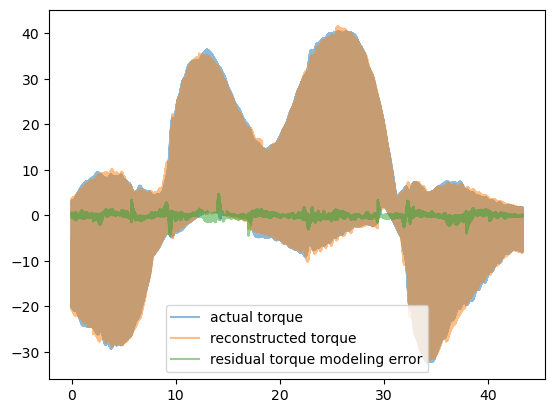

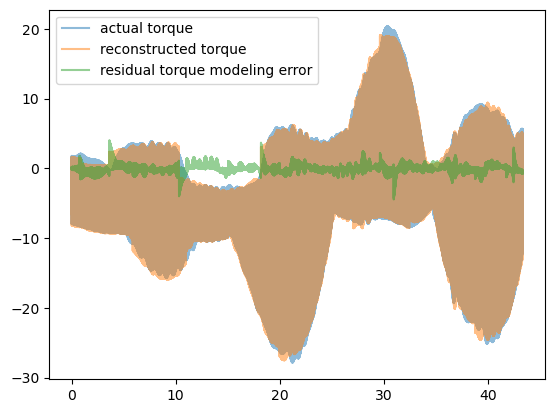

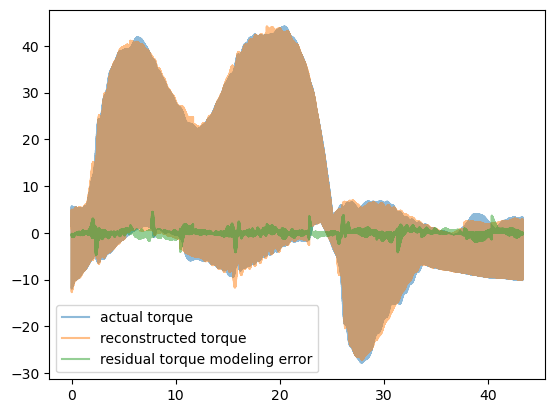

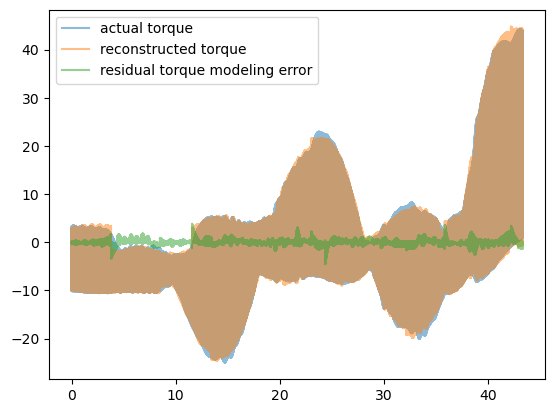

In [369]:
###################################
## RESIDUAL + RBD compare to TRUE ##

torque_reconstructed = torque_residual_compare + tau_rbd
tau_residual = tau_residual.reshape(-1,1)

from matplotlib import pyplot as plt
plt.close()

print("torque_reconstructed.shape", torque_reconstructed.shape)
print("tau_vec.shape", tau_vec.shape)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    steps = tau_vec.shape[0]
    j = steps//rbt.dof

    plt.plot(t, tau_vec[j*i:j*(i+1)], alpha = 0.5, label='actual torque') # actual torque
    plt.plot(t, torque_reconstructed[j*i:j*(i+1)],  alpha = 0.5,  label='reconstructed torque') # modeled by rbd
    plt.plot(t, (torque_residual_compare-tau_residual)[j*i:j*(i+1)],  alpha = 0.5,  label='residual torque modeling error') # actual torque
    
   
    plt.legend()
    plt.show()